In [4]:
!pip install seaborn

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, RandomFlip, RandomZoom,RandomRotation
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "preprocessed_dataset/train",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "preprocessed_dataset/test",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)



model = Sequential([
    Input(shape = (48, 48, 3)),

    # Data Augmentation
    Rescaling(1/255),
    RandomFlip('horizontal'),
    RandomZoom(0.1),
    RandomRotation(0.1),

    # Set 1 of neural networks
    Conv2D(64, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Set 2 of neural networks
    Conv2D(128, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Set 3 of neural networks
    Conv2D(256, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding= "same", activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Dense Layer
    GlobalAveragePooling2D(),
    Dense(256, activation= 'relu'),
    Dropout(0.25),

    # last set
    Dense(7, activation= 'softmax')
])

model.summary()


model.compile(
    optimizer= "adam",
    loss = "SparseCategoricalCrossentropy",
    metrics = ["SparseCategoricalAccuracy"]
)



callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
    "Model.keras",
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
),

#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         min_delta=0.01,
#         patience=5,
#         verbose=1,
#         mode='auto',
#         baseline=None,
#         restore_best_weights=False,
#         start_from_epoch=0
# ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    mode='auto'
)
]

model.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 20,
    callbacks = callbacks
)

Found 27473 files belonging to 7 classes.
Found 7092 files belonging to 7 classes.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 48, 48, 3)         0         
                                                                 
 random_flip_2 (RandomFlip)  (None, 48, 48, 3)         0         
                                                                 
 random_zoom_2 (RandomZoom)  (None, 48, 48, 3)         0         
                                                                 
 random_rotation_2 (RandomRo  (None, 48, 48, 3)        0         
 tation)                                                         
                                                                 
 conv2d_12 (Conv2D)          (None, 48, 48, 64)        1792      
                                                                 
 batch_normalization_12 (Bat  (None, 

In [12]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "preprocessed_dataset/test",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)

y_true = []
y_predict = []
for images, labels in test_ds:
    predict = model.predict(images)
    y_predict.extend(tf.argmax(predict, axis=1).numpy())
    y_true.extend(labels.numpy())

Found 7092 files belonging to 7 classes.
1/1 [==============================] - 0s 235ms/step


In [14]:
class_name = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print(classification_report(y_true, y_predict, target_names= class_name))

              precision    recall  f1-score   support

       angry       0.57      0.44      0.50       946
     disgust       0.41      0.27      0.32       109
        fear       0.41      0.32      0.36      1013
       happy       0.80      0.85      0.82      1767
     neutral       0.50      0.64      0.56      1225
         sad       0.49      0.50      0.49      1240
    surprise       0.69      0.69      0.69       792

    accuracy                           0.59      7092
   macro avg       0.55      0.53      0.54      7092
weighted avg       0.59      0.59      0.59      7092



In [15]:
cm = confusion_matrix(y_true, y_predict)
cm

array([[ 414,   17,   89,   55,  160,  169,   42],
       [  38,   29,   10,   10,    6,   14,    2],
       [  96,   12,  327,   61,  166,  243,  108],
       [  34,    2,   51, 1503,  108,   32,   37],
       [  42,    2,   66,  118,  782,  185,   30],
       [  75,    6,  134,   89,  296,  618,   22],
       [  23,    2,  117,   43,   51,   12,  544]], dtype=int64)

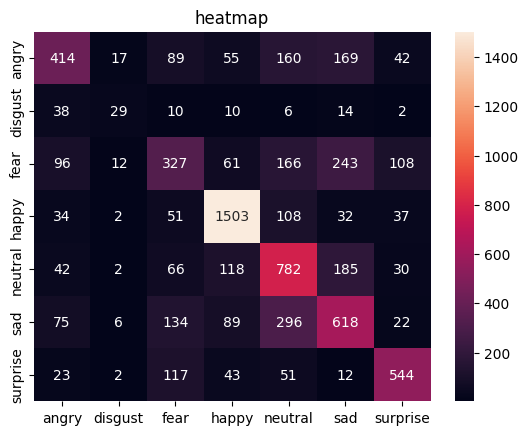

In [16]:
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_name, yticklabels= class_name)
plt.title("heatmap")
plt.show()